# Diabetes Risk Prediction Using Machine Learning

This notebook builds and evaluates classification models to predict diabetes risk using cleaned patient health data.

> **Healthcare Disclaimer:** This project is for educational and analytical purposes only. It is not intended for clinical diagnosis or medical decision-making.


## 1. Machine Learning Objective

The goal is to classify patients into:

- `0`: No Diabetes
- `1`: Diabetes

Because this is a healthcare-related classification project, evaluation should not rely only on accuracy. Recall, F1-score, and ROC-AUC are important because missing a diabetes-risk patient can be more serious than a false positive.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [2]:
df = pd.read_csv("../data/processed/diabetes_cleaned.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,glucose_category,bmi_category,age_group,risk_label
0,6,148.0000,72.0000,35.0000,125.0000,33.6000,0.6270,50,1,Diabetes Range,Obese,41-50,Diabetes
1,1,85.0000,66.0000,29.0000,125.0000,26.6000,0.3510,31,0,Normal,Overweight,31-40,No Diabetes
2,8,183.0000,64.0000,29.0000,125.0000,23.3000,0.6720,32,1,Diabetes Range,Normal,31-40,Diabetes
3,1,89.0000,66.0000,23.0000,94.0000,28.1000,0.1670,21,0,Normal,Overweight,21-30,No Diabetes
4,0,137.0000,40.0000,35.0000,168.0000,43.1000,2.2880,33,1,Diabetes Range,Obese,31-40,Diabetes


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df["Outcome"].value_counts(normalize=True).round(4)

Rows: 768
Columns: 13


Outcome
0   0.6510
1   0.3490
Name: proportion, dtype: float64

## 2. Feature Selection

The model uses numeric health indicators as input features. The target variable is `Outcome`.


In [5]:
feature_cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

X = df[feature_cols]
y = df["Outcome"]

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0000,72.0000,35.0000,125.0000,33.6000,0.6270,50
1,1,85.0000,66.0000,29.0000,125.0000,26.6000,0.3510,31
2,8,183.0000,64.0000,29.0000,125.0000,23.3000,0.6720,32
3,1,89.0000,66.0000,23.0000,94.0000,28.1000,0.1670,21
4,0,137.0000,40.0000,35.0000,168.0000,43.1000,2.2880,33


## 3. Stratified Train-Test Split

A stratified split preserves the diabetes/no-diabetes ratio in both training and testing sets.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training distribution:
Outcome
0   0.6515
1   0.3485
Name: proportion, dtype: float64

Testing distribution:
Outcome
0   0.6494
1   0.3506
Name: proportion, dtype: float64


## 4. Model Training with Pipelines

Pipelines are used to prevent data leakage. Scaling happens only inside the training pipeline.


In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=11))
    ]),
    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(random_state=42, max_depth=5))
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=150, random_state=42, max_depth=6))
    ]),
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

In [8]:
results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "cv_roc_auc": cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc").mean(),
        "cv_f1_score": cross_val_score(model, X_train, y_train, cv=5, scoring="f1").mean()
    })

    predictions[name] = y_pred
    probabilities[name] = y_proba

model_performance = pd.DataFrame(results).sort_values(
    ["roc_auc", "recall", "f1_score"], ascending=False
).round(4)

model_performance

,model,accuracy,precision,recall,f1_score,roc_auc,cv_roc_auc,cv_f1_score
4,Gradient Boosting,0.7597,0.6889,0.5741,0.6263,0.8315,0.8150,0.6424
3,Random Forest,0.7403,0.6667,0.5185,0.5833,0.8137,0.8327,0.6334
0,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130,0.8433,0.6497
1,KNN,0.7338,0.6327,0.5741,0.6019,0.7867,0.8224,0.6257
2,Decision Tree,0.7597,0.6393,0.7222,0.6783,0.7622,0.7477,0.5643


## 5. Random Forest Hyperparameter Tuning

A tuned Random Forest model is added because it performs well on tabular data and provides useful feature importance.


In [9]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 6, None],
    "model__min_samples_leaf": [1, 3]
}

rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validated ROC-AUC:")
print(round(grid.best_score_, 4))

Best Parameters:
{'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}

Best Cross-Validated ROC-AUC:
0.8372


In [10]:
tuned_rf = grid.best_estimator_

tuned_pred = tuned_rf.predict(X_test)
tuned_proba = tuned_rf.predict_proba(X_test)[:, 1]

tuned_result = pd.DataFrame([{
    "model": "Tuned Random Forest",
    "accuracy": accuracy_score(y_test, tuned_pred),
    "precision": precision_score(y_test, tuned_pred),
    "recall": recall_score(y_test, tuned_pred),
    "f1_score": f1_score(y_test, tuned_pred),
    "roc_auc": roc_auc_score(y_test, tuned_proba),
    "cv_roc_auc": grid.best_score_,
    "cv_f1_score": cross_val_score(tuned_rf, X_train, y_train, cv=5, scoring="f1").mean()
}])

model_performance_final = pd.concat(
    [model_performance, tuned_result],
    ignore_index=True
).sort_values(["roc_auc", "recall", "f1_score"], ascending=False).round(4)

model_performance_final

,model,accuracy,precision,recall,f1_score,roc_auc,cv_roc_auc,cv_f1_score
0,Gradient Boosting,0.7597,0.6889,0.5741,0.6263,0.8315,0.8150,0.6424
1,Random Forest,0.7403,0.6667,0.5185,0.5833,0.8137,0.8327,0.6334
2,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130,0.8433,0.6497
5,Tuned Random Forest,0.7273,0.6579,0.4630,0.5435,0.7981,0.8372,0.6112
3,KNN,0.7338,0.6327,0.5741,0.6019,0.7867,0.8224,0.6257
4,Decision Tree,0.7597,0.6393,0.7222,0.6783,0.7622,0.7477,0.5643


## 6. Final Model Selection

The final model is selected using ROC-AUC, recall, and F1-score.


In [11]:
final_model_name = model_performance_final.iloc[0]["model"]

if final_model_name == "Tuned Random Forest":
    final_model = tuned_rf
    final_pred = tuned_pred
    final_proba = tuned_proba
else:
    final_model = models[final_model_name]
    final_pred = predictions[final_model_name]
    final_proba = probabilities[final_model_name]

print(f"Final Model: {final_model_name}")

Final Model: Gradient Boosting


In [12]:
print(classification_report(y_test, final_pred, target_names=["No Diabetes", "Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.79      0.86      0.82       100
    Diabetes       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



In [13]:
cm = confusion_matrix(y_test, final_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual No Diabetes", "Actual Diabetes"],
    columns=["Predicted No Diabetes", "Predicted Diabetes"]
)
cm_df

,Predicted No Diabetes,Predicted Diabetes
Actual No Diabetes,86,14
Actual Diabetes,23,31


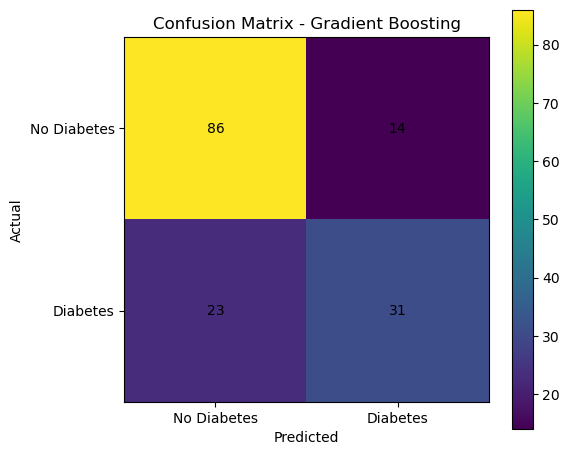

In [14]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix - {final_model_name}")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["No Diabetes", "Diabetes"])
plt.yticks(tick_marks, ["No Diabetes", "Diabetes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=150)
plt.show()

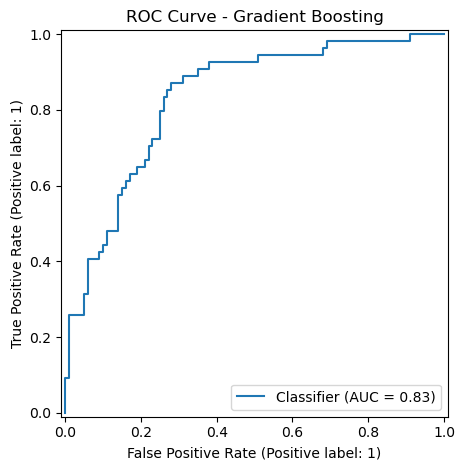

In [15]:
RocCurveDisplay.from_predictions(y_test, final_proba)
plt.title(f"ROC Curve - {final_model_name}")
plt.tight_layout()
plt.savefig("../images/roc_curve.png", dpi=150)
plt.show()

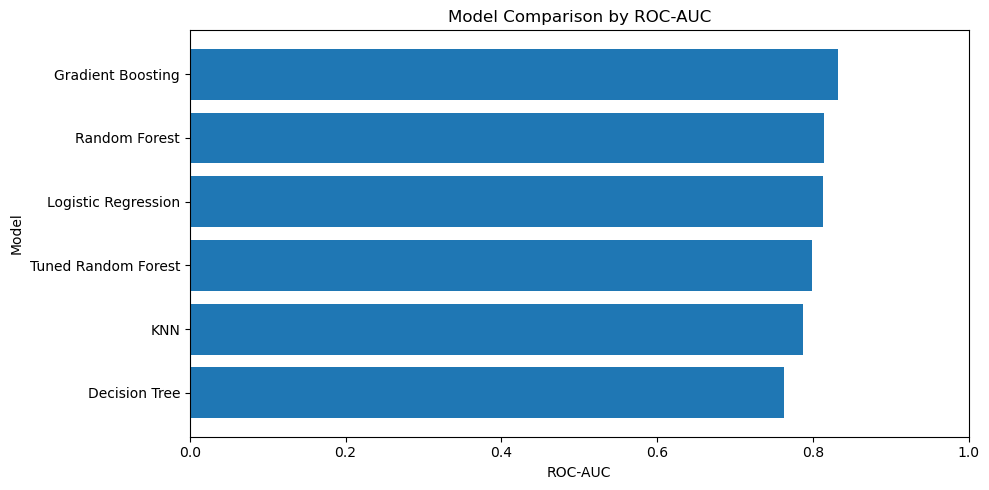

In [16]:
plot_data = model_performance_final.sort_values("roc_auc")

plt.figure(figsize=(10, 5))
plt.barh(plot_data["model"], plot_data["roc_auc"])
plt.title("Model Comparison by ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("../images/model_comparison_roc_auc.png", dpi=150)
plt.show()

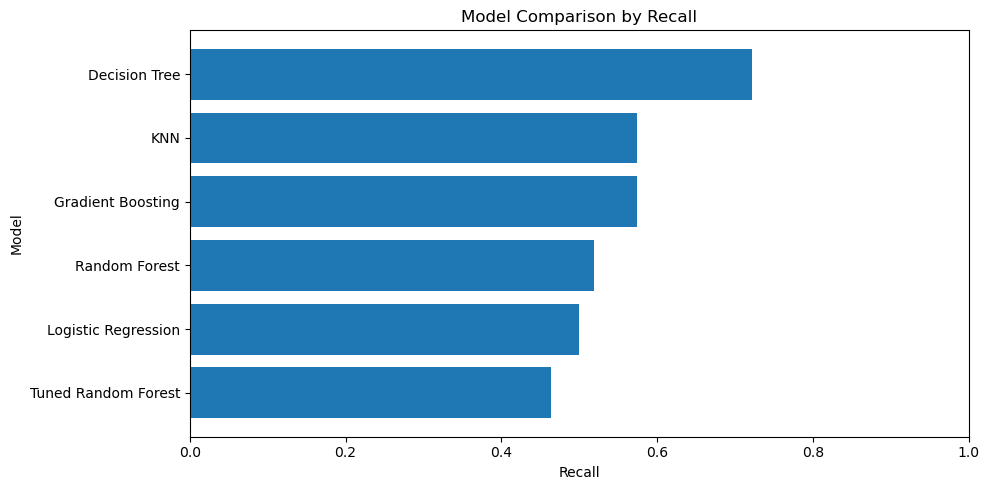

In [17]:
plot_data = model_performance_final.sort_values("recall")

plt.figure(figsize=(10, 5))
plt.barh(plot_data["model"], plot_data["recall"])
plt.title("Model Comparison by Recall")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("../images/model_comparison_recall.png", dpi=150)
plt.show()

## 7. Feature Importance

Feature importance helps explain which health indicators contribute most to diabetes risk prediction.


In [18]:
if final_model_name in ["Random Forest", "Gradient Boosting", "Tuned Random Forest"]:
    importances = final_model.named_steps["model"].feature_importances_
elif final_model_name == "Logistic Regression":
    importances = np.abs(final_model.named_steps["model"].coef_[0])
else:
    importances = tuned_rf.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance.round(4)

,feature,importance
1,Glucose,0.4135
5,BMI,0.1939
7,Age,0.1169
6,DiabetesPedigreeFunction,0.1083
4,Insulin,0.0797
0,Pregnancies,0.0541
3,SkinThickness,0.0178
2,BloodPressure,0.0158


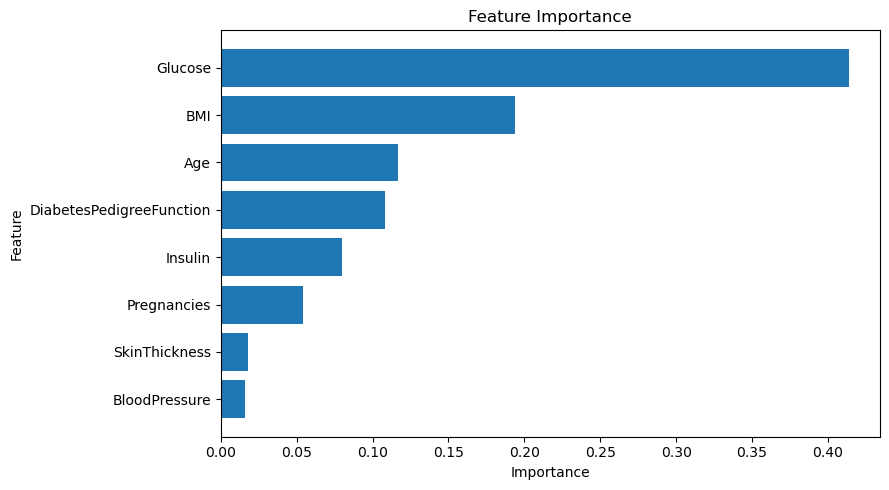

In [19]:
plot_data = feature_importance.sort_values("importance")

plt.figure(figsize=(9, 5))
plt.barh(plot_data["feature"], plot_data["importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=150)
plt.show()

## 8. Dashboard-Ready Prediction Outputs

In [21]:
pred_df = X_test.copy()
pred_df["actual_outcome"] = y_test.values
pred_df["predicted_outcome"] = final_pred
pred_df["diabetes_probability"] = np.round(final_proba, 4)
pred_df["actual_label"] = pred_df["actual_outcome"].map({0: "No Diabetes", 1: "Diabetes"})
pred_df["predicted_label"] = pred_df["predicted_outcome"].map({0: "No Diabetes", 1: "Diabetes"})
pred_df["prediction_correct"] = pred_df["actual_outcome"] == pred_df["predicted_outcome"]

pred_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,actual_outcome,predicted_outcome,diabetes_probability,actual_label,predicted_label,prediction_correct
44,7,159.0000,64.0000,29.0000,125.0000,27.4000,0.2940,40,0,1,0.8429,No Diabetes,Diabetes,False
672,10,68.0000,106.0000,23.0000,49.0000,35.5000,0.2850,47,0,0,0.0555,No Diabetes,No Diabetes,True
700,2,122.0000,76.0000,27.0000,200.0000,35.9000,0.4830,26,0,0,0.0885,No Diabetes,No Diabetes,True
630,7,114.0000,64.0000,29.0000,125.0000,27.4000,0.7320,34,1,0,0.4459,Diabetes,No Diabetes,False
81,2,74.0000,72.0000,29.0000,125.0000,32.3000,0.1020,22,0,0,0.0115,No Diabetes,No Diabetes,True


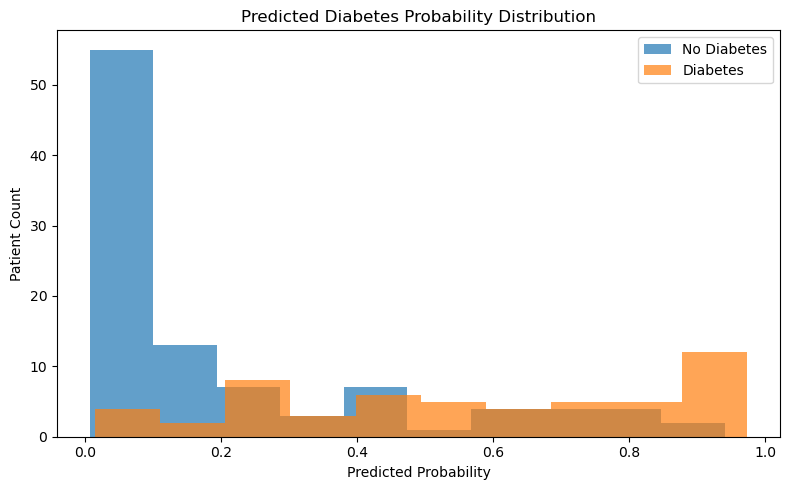

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(pred_df[pred_df["actual_outcome"] == 0]["diabetes_probability"], alpha=0.7, label="No Diabetes")
plt.hist(pred_df[pred_df["actual_outcome"] == 1]["diabetes_probability"], alpha=0.7, label="Diabetes")
plt.title("Predicted Diabetes Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Patient Count")
plt.legend()
plt.tight_layout()
plt.savefig("../images/prediction_probability_distribution.png", dpi=150)
plt.show()

In [24]:
model_performance_final.to_csv("../data/processed/model_performance.csv", index=False)
pred_df.to_csv("../data/processed/diabetes_predictions.csv", index=False)
feature_importance.to_csv("../data/processed/feature_importance.csv", index=False)
cm_df.to_csv("../data/processed/confusion_matrix.csv")

risk_bins = pd.cut(
    pred_df["diabetes_probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

risk_summary = pred_df.assign(risk_group=risk_bins).groupby("risk_group", observed=False).agg(
    patient_count=("diabetes_probability", "count"),
    avg_probability=("diabetes_probability", "mean"),
    diabetes_rate=("actual_outcome", "mean")
).reset_index()

risk_summary.to_csv("../data/processed/risk_summary.csv", index=False)

print("outputs exported successfully.")

outputs exported successfully.


## 9.Summary

This notebook improves the project by:

- Using stratified train-test splitting
- Preventing data leakage with pipelines
- Comparing multiple classification models
- Evaluating with accuracy, precision, recall, F1-score, ROC-AUC, and cross-validation
- Tuning Random Forest
- Creating feature importance analysis
- Exporting dashboard-ready model outputs
